# Lista 6
### Maria Nowacka 275981

In [2]:
import numpy as np, matplotlib.pyplot as plt, time, pandas as pd
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine, fetch_lfw_people
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


### zadanie 1
Wprowadzenie do PCA: Wygeneruj syntetyczny zbiór danych w
3D, w którym punkty układają się w linii lub płaszczyźnie. Użyj klasy
`PCA` z `scikit-learn`, aby zredukować wymiarowość do 2D. Zwizualizuj
dane przed i po redukcji.

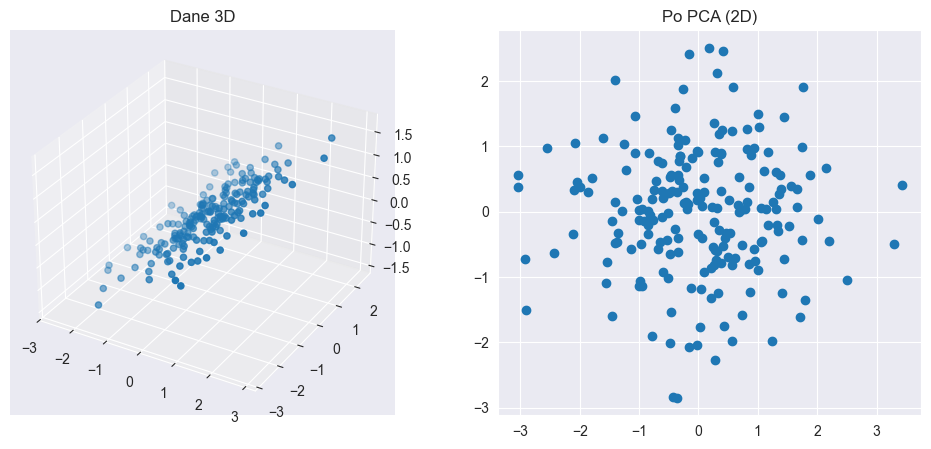

In [28]:
X = np.random.randn(200, 2)
z = 0.5 * X[:,0] + 0.2 * X[:,1] + np.random.normal(0, 0.05, 200)
X3d = np.column_stack((X, z))

pca = PCA(n_components=2)
X2d = pca.fit_transform(X3d)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(121, projection='3d')
ax.scatter(X3d[:,0], X3d[:,1], X3d[:,2])
ax.set_title("Dane 3D")

plt.subplot(122)
plt.scatter(X2d[:,0], X2d[:,1])
plt.title("Po PCA (2D)")
plt.show()

### zadanie 2
Analiza wariancji: Dla zbioru danych Iris lub Wine użyj PCA i wygeneruj wykres wariancji wyjaśnionej. Zinterpretuj, ile głównych składowych należy zachować, aby wyjaśnić 95% całkowitej wariancji.

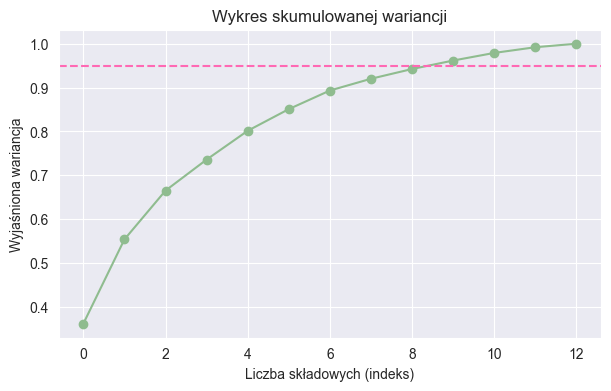

Liczba składowych potrzebna do 95% wariancji: 10


In [14]:
data = load_wine()
X = StandardScaler().fit_transform(data.data)

pca = PCA().fit(X)

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='darkseagreen')
plt.axhline(0.95, color='hotpink', linestyle='--')
plt.title("Wykres skumulowanej wariancji")
plt.xlabel("Liczba składowych (indeks)")
plt.ylabel("Wyjaśniona wariancja")
plt.show()

k = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print("Liczba składowych potrzebna do 95% wariancji:", k)

### zadanie 3
Wizualizacja wielowymiarowych danych: Zastosuj PCA do zbioru
danych `Iris` lub `Wine`, redukując go do 2 głównych składowych. Stwórz wykres punktowy w 2D, kolorując punkty według ich klasy. Wyjaśnij, czy PCA jest skuteczną metodą do wizualizacji w tym przypadku.

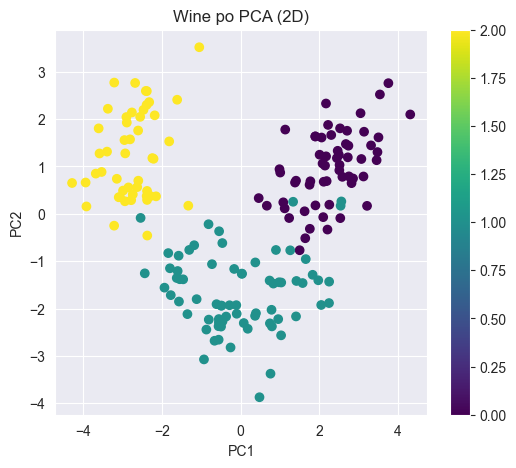

In [6]:
y = data.target

pca = PCA(n_components=2)
X2d = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2d[:,0], X2d[:,1], c=y, cmap="viridis")
plt.title("Wine po PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

Nie rozdziela optymalnie klas ale działa spoko jako wizuzalizacja.

### zadanie 4
PCA jako pre-processing: Wytrenuj model klasyfikacyjny (np. Regresję Logistyczną lub SVM) na danych `Wine` bez redukcji wymiarowości. Następnie, zastosuj PCA, redukując dane do 2 głównych składowych, i ponownie wytrenuj ten sam model. Porównaj dokładność i czas treningu w obu przypadkach.

In [43]:
data = load_wine()
X = StandardScaler().fit_transform(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

model1 = SVC()
t0 = time.time()
model1.fit(X_train, y_train)
t1 = time.time()
t_svc = t1 - t0
acc1 = model1.score(X_test, y_test)

model2 = LogisticRegression()
t0 = time.time()
model2.fit(X_train, y_train)
t1 = time.time()
t_lr = t1 - t0
acc2 = model2.score(X_test, y_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
model3 = LogisticRegression()
t0 = time.time()
model3.fit(X_train, y_train)
t1 = time.time()
t_lr2 = t1 - t0
acc3 = model3.score(X_test, y_test)

model4 = SVC()
t0 = time.time()
model4.fit(X_train, y_train)
t1 = time.time()
t_svc2 = t1 - t0
acc4 = model4.score(X_test, y_test)


wyniki = {
    'Konfiguracja': ['Bez PCA', 'Z PCA', 'Bez PCA', 'Z PCA'],
    'Model': ['LR', 'LR', 'SVC', 'SVC'],
    'Accuracy': [acc1, acc2, acc3, acc4],
    'Czas trenowania (s)': [t_lr, t_lr2, t_svc, t_svc2]
}
df = pd.DataFrame(wyniki)
print(df)

  Konfiguracja Model  Accuracy  Czas trenowania (s)
0      Bez PCA    LR  1.000000             0.082444
1        Z PCA    LR  0.977778             0.007203
2      Bez PCA   SVC  0.977778             0.041647
3        Z PCA   SVC  1.000000             0.004106


### zadanie 5
Liniowa Analiza Dyskryminacyjna (LDA): Wytrenuj model LDA
(`LinearDiscriminantAnalysis` z `scikit-learn`) na zbiorze danych
Wine. Zredukuj dane do 2 wymiarów i zwizualizuj je. Porównaj wyniki z wizualizacją uzyskaną za pomocą PCA i omów różnice w podejściu.

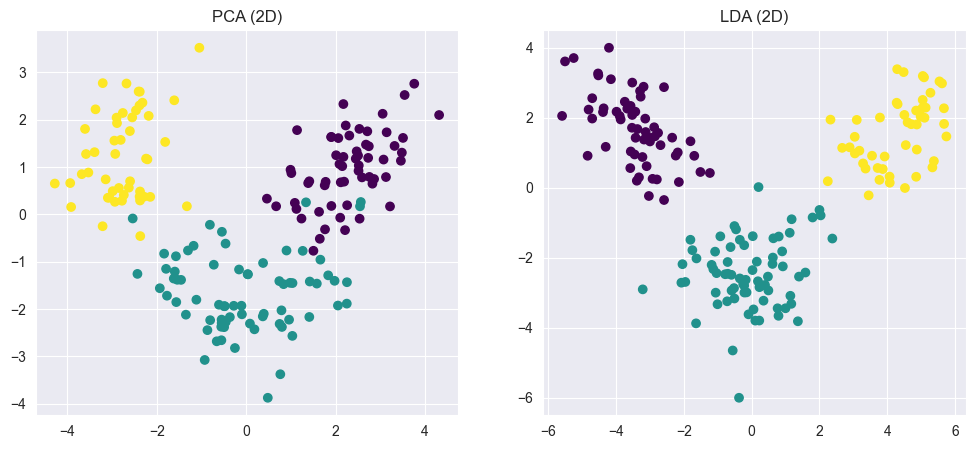

In [8]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.scatter(X2d[:,0], X2d[:,1], c=y, cmap="viridis")
plt.title("PCA (2D)")

plt.subplot(122)
plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap="viridis")
plt.title("LDA (2D)")

plt.show()

* PCA - szuka kierunków największej wariancji (bez etykiet)

* LDA - szuka kierunków najlepiej rozdzielających klasy (z etykietami)

* LDA zwykle lepiej separuje klasy, bo używa informacji o etykietach

* Do wizualizacji klas - LDA zazwyczaj „wygrywa” nad PCA

### zadanie 6
Zastosowanie na danych rzeczywistych: Wczytaj zbiór danych do
rozpoznawania twarzy (`LFW - Labeled Faces in the Wild`, dostęp-
ny w `scikit-learn`). Zastosuj PCA, aby zredukować wymiarowość obrazów. Wyświetl oryginalne obrazy i ich zrekonstruowane wersje po redukcji i dekompresji.

In [44]:
lfw = fetch_lfw_people(min_faces_per_person=60)
X = lfw.data
h, w = lfw.images[0].shape

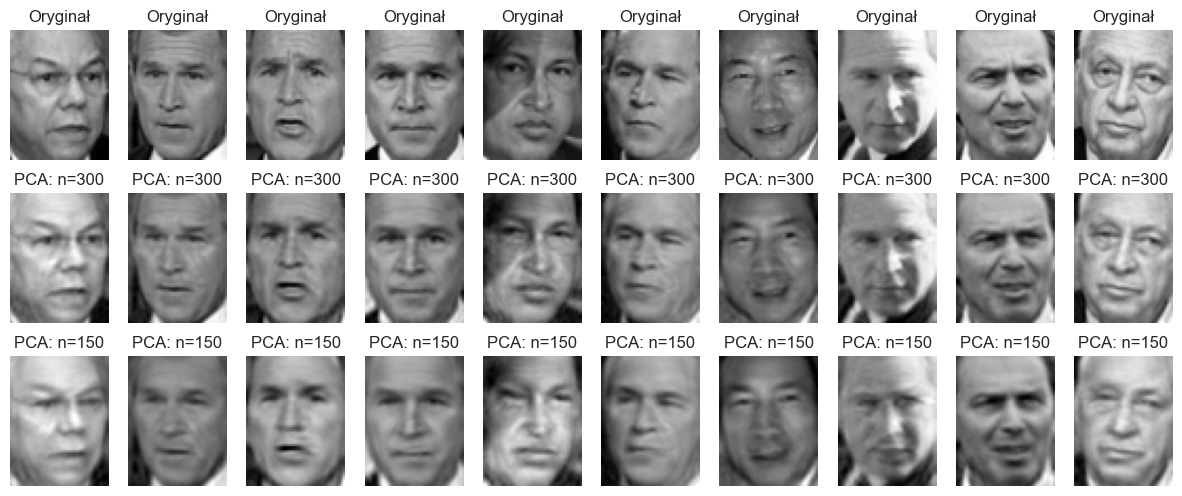

In [50]:
pca = PCA(n_components=300, whiten=True)
X_pca = pca.fit_transform(X)

X_reconstructed = pca.inverse_transform(X_pca)

pca2 = PCA(n_components=150, whiten=True)
X_pca2 = pca2.fit_transform(X)

X_reconstructed2 = pca2.inverse_transform(X_pca2)

fig, axes = plt.subplots(3, 10, figsize=(15,6))

for i in range(10):
    axes[0,i].imshow(lfw.images[i], cmap=plt.cm.gray)
    axes[0,i].axis('off')
    axes[0,i].set_title("Oryginał")

    axes[1,i].imshow(X_reconstructed[i].reshape(h, w), cmap=plt.cm.gray)
    axes[1,i].axis('off')
    axes[1,i].set_title("PCA: n=300")

    axes[2,i].imshow(X_reconstructed2[i].reshape(h, w), cmap='gray')
    axes[2,i].axis('off')
    axes[2,i].set_title("PCA: n=150")
plt.show()


(n$\times$m pikseli -> spłaszczany do wektora długości n$\cdot$m, obliczenie średniego wektora twarzy, koonstrukcja macierzy kowariancji -> wektory własne macierzy -> macierz 2d (rozmazane twarze - Eigenfaces) -> oryginalne zdjęcie rzutowane na ileś najważnijeszych Eigenfaces (zachowujemy tylko kluczowe informacje) -> dostajemy zrekonstruowany obraz = suma średniej twarzy + lin(Eigenfaces)

* PCA kompresuje obraz do mniejszej liczby cech
* Rekonstrukcja jest rozmyta → tracimy szczegóły
* To podejście nazywa się „Eigenfaces”